# 사용자 가입 분석 (Accquisition)

* 서비스 특성 : 중·고등학생 타깃 특성상 리텐션(Retention)이 높아도 진급 및 졸업으로 인한 구조적 자연 이탈이 불가피한 특성을 가지고 있습니다.

* 이탈분을 상쇄하고 지속 가능한 성장을 도모하기 위해, 체계적인 신규 사용자 획득 (`Accquisition`)이 필수 과제라고 판단됩니다.

## 라이브러리 호출

In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="darkgrid")

plt.rc('font', family='AppleGothic')
# 마이너스 폰트 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False

## 데이터 호출

In [5]:
from google.cloud import bigquery

PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

In [6]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.stg_acquisition_user`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

   user_id                      signup_date  group_id  grade  school_id  \
0   868806 2023-05-02 03:30:58.454799+00:00      8799      1       4783   
1   868974 2023-05-02 04:18:16.334717+00:00      6753      1        281   
2   870723 2023-05-02 11:19:58.393218+00:00      5933      1       2412   
3   961125 2023-05-07 11:18:28.897540+00:00     26806      1       4678   
4   962914 2023-05-07 11:49:02.822956+00:00     19439      1       5060   

        address school_type  
0   경기도 용인시 수지구           H  
1  충청남도 천안시 서북구           H  
2     서울특별시 광진구           H  
3       경기도 이천시           H  
4       경기도 시흥시           H  


## 기본 현상 분석

### 월별 가입자 추이 분석

In [7]:
# datetime 변환 후 YYYY-MM 포맷으로 추출
df['signup_month'] = pd.to_datetime(df['signup_date']).dt.strftime('%Y-%m')

# 연월별 유니크 가입자 수 집계
monthly_summary = df.groupby(by='signup_month')['user_id'].nunique().reset_index(name='unique_users')
print(monthly_summary.head())

  signup_month  unique_users
0      2023-03            22
1      2023-04         19030
2      2023-05        635478
3      2023-06         16734
4      2023-07          1833


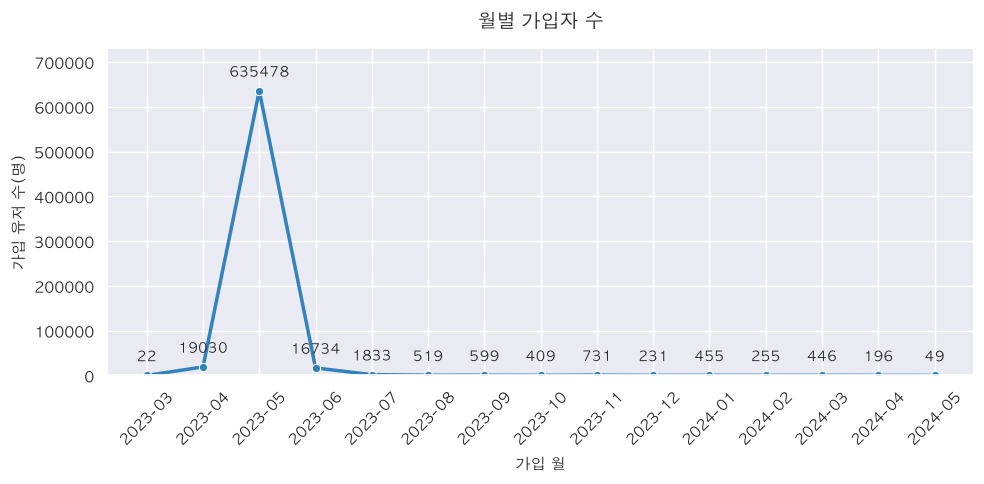

In [14]:
plt.figure(figsize=(10, 5))

# 라인그래프 생성
ax = sns.lineplot(
    data=monthly_summary,
    x='signup_month',
    y='unique_users',
    marker='o',
    linewidth=2.5,
    color='#3182bd'
)

# 각 데이터 포인트에 숫자 레이블 표시
for x, y in zip(monthly_summary['signup_month'], monthly_summary['unique_users']):
    ax.annotate(
        f'{int(y)}',
        (x, y),
        ha='center',
        va='bottom',
        xytext=(0, 7),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.title('월별 가입자 수', fontsize=14, pad=15)
plt.xlabel('가입 월', fontsize=11)
plt.ylabel('가입 유저 수(명)', fontsize=11)

plt.xticks(rotation=45)
plt.ylim(0, monthly_summary['unique_users'].max() * 1.15)

plt.tight_layout()
plt.show()

* 5월에 가입자 수가 폭발적으로 증가했으나, 6월에는 급격히 감소하며 상승세가 지속되지 못함

### 중학교 / 고등학교 유저 수 비교

In [23]:
school_summary = (
    df.groupby('school_type')['user_id']
      .nunique()
      .reset_index(name='unique_users')
)

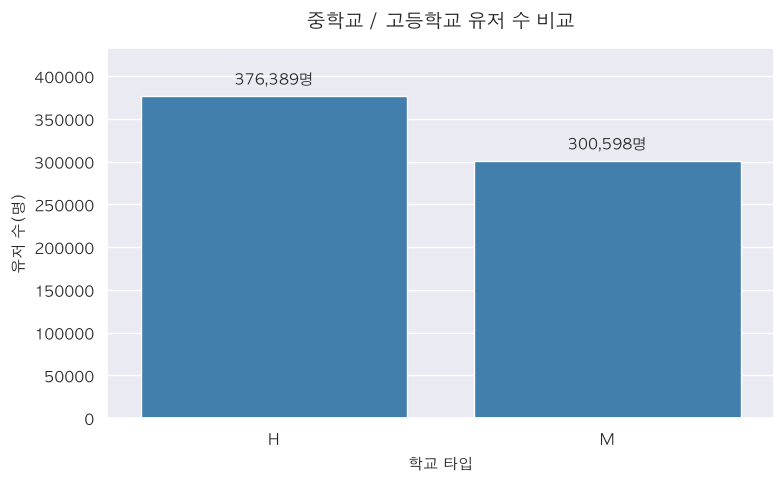

In [24]:
plt.figure(figsize=(8, 5))

# 막대그래프
ax = sns.barplot(
    data=school_summary,
    x='school_type',
    y='unique_users',
    color='#3182bd'
)

# 막대 위에 숫자 표시
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height):,}명',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

plt.title('중학교 / 고등학교 유저 수 비교', fontsize=14, pad=15)
plt.xlabel('학교 타입', fontsize=11)
plt.ylabel('유저 수(명)', fontsize=11)

# 위쪽 숫자가 잘리지 않도록 여유 공간
plt.ylim(0, school_summary['unique_users'].max() * 1.15)

plt.tight_layout()
plt.show()

### 도시 별 유저 수 비교

In [26]:
df[df['address'] == '-']

,user_id,signup_date,group_id,grade,school_id,address,school_type,signup_month
227072,1579162,2023-07-20 12:49:32.065000+00:00,84010,2,5949,-,H,2023-07
554755,1567177,2023-06-04 03:24:48.547540+00:00,83099,3,5948,-,H,2023-06
572583,1567167,2023-06-04 03:19:17.888642+00:00,83099,3,5948,-,H,2023-06


## 집단 가입 패턴 및 확산 속도 분석

* 

## 집단 별 가입 시계열 확인

* 가입 일자별 학급 단위 학교 단위 신규 가입자 수 추이 시각화

유저, 가입일자, 그룹, 학년, 학교, 지역

| id | created_at | group_id | => user<br>
| id | grade | school_id | => group<br>
| id | adress | school_type | => school<br>
(| distance | nearby_school_id | school_id | => nearbyschool)

| user_id | sign_up_date | group_id | grade | school_id | school_type | address | 